# Loan Default Risk Assessment Model

This notebook builds a probability of default model for loan applicants using logistic regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

## 1. Load and Combine Data Sources

In [2]:
# Read data from different sources
applicant_info = pd.read_excel('customer_scorecard_input.xlsx', sheet_name='Application_Data')
payment_behavior = pd.read_excel('customer_scorecard_input.xlsx', sheet_name='Behavioral_Data')
credit_history = pd.read_excel('bureau_data.xlsx', sheet_name='Bureau_Data')

# Merge all datasets
full_data = applicant_info.merge(payment_behavior, on='Customer_ID', how='inner')
full_data = full_data.merge(credit_history, on='Customer_ID', how='inner')

print(f"Total records: {len(full_data)}")
print(f"Total features: {len(full_data.columns)}")
full_data.head()

Total records: 100
Total features: 34


,Customer_ID,Age,Income_INR,Employment_Years,Marital_Status,Education_Level,Credit_History_Length,Outstanding_Loans,Loan_Amount,Loan_Tenure_Months,...,No_of_Inquiries_12M,DPD_30,DPD_60,DPD_90,Worst_Current_Status,Months_Since_Most_Recent_Delinquency,Max_Credit_Exposure,Oldest_Trade_Open_Months,Newest_Trade_Open_Months,Default_y
0,1,59,2309818,0,Divorced,Graduate,5,9,448929,48,...,5,2,0,1,0,56,989211,227,49,1
1,2,49,2431785,8,Divorced,Postgraduate,12,6,630466,24,...,0,0,0,1,0,6,1626107,237,25,0
2,3,35,488998,27,Single,Graduate,16,9,623695,72,...,3,0,1,0,1,21,697160,225,40,0
3,4,63,2043400,26,Single,High School,16,4,513556,24,...,0,0,0,1,3,54,1930947,142,24,0
4,5,28,1279111,5,Divorced,Graduate,7,2,625278,24,...,5,1,1,1,0,32,339972,87,14,0


## 2. Define Target Variable

We define a customer as 'bad' if they have been 90+ days past due

In [3]:
# Create target: 1 if customer defaulted (90+ days past due), 0 otherwise
full_data['is_defaulter'] = (full_data['DPD_90'] >= 1).astype(int)

default_rate = full_data['is_defaulter'].mean() * 100
print(f"Default rate in dataset: {default_rate:.2f}%")
print(f"Good customers: {(full_data['is_defaulter']==0).sum()}")
print(f"Bad customers: {(full_data['is_defaulter']==1).sum()}")

Default rate in dataset: 59.00%
Good customers: 41
Bad customers: 59


## 3. Feature Selection

Select relevant features for modeling

In [4]:
# Use only most stable predictive features
numeric_features = [
    'Credit_Card_Utilization', 'Credit_Utilization_Ratio',
    'Behavior_Repayment_Score', 'Outstanding_Loans',
    'Total_Credit_Limit', 'Total_Current_Balance'
]

# Create modeling dataset
model_data = full_data[numeric_features + ['is_defaulter']].copy()
model_data = model_data.dropna()

print(f"Features selected: {len(numeric_features)}")
print(f"Records after removing missing values: {len(model_data)}")

Features selected: 6
Records after removing missing values: 100


## 4. Create Bins for Continuous Variables

Group continuous variables into categories for easier interpretation

In [5]:
def create_bins(data, column, num_bins=5):
    """
    Create equal-frequency bins for a continuous variable
    """
    try:
        bins = pd.qcut(data[column], q=num_bins, duplicates='drop')
        return bins
    except:
        # If qcut fails, use cut instead
        bins = pd.cut(data[column], bins=num_bins)
        return bins

# Create bins for key variables
binned_data = model_data.copy()

for col in ['Credit_Card_Utilization', 'Credit_Utilization_Ratio']:
    binned_data[f'{col}_bin'] = create_bins(binned_data, col, num_bins=4)

print("Binning completed for key variables")

Binning completed for key variables


## 5. Calculate Weight of Evidence (WOE)

WOE measures the strength of each category in predicting default

In [6]:
def calculate_woe_iv(data, feature, target):
    """
    Calculate Weight of Evidence and Information Value
    """
    # Group by feature and calculate good/bad counts
    grouped = data.groupby(feature)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']
    
    # Calculate percentages
    grouped['bad_pct'] = grouped['bad'] / grouped['bad'].sum()
    grouped['good_pct'] = grouped['good'] / grouped['good'].sum()
    
    # Avoid division by zero
    grouped['bad_pct'] = grouped['bad_pct'].replace(0, 0.0001)
    grouped['good_pct'] = grouped['good_pct'].replace(0, 0.0001)
    
    # Calculate WOE
    grouped['woe'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
    
    # Calculate IV
    grouped['iv'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['woe']
    
    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv

# Calculate WOE for binned variables
woe_results = {}
iv_values = {}

for col in binned_data.columns:
    if col.endswith('_bin'):
        woe_df, iv = calculate_woe_iv(binned_data, col, 'is_defaulter')
        woe_results[col] = woe_df
        iv_values[col] = iv
        print(f"\n{col}:")
        print(f"Information Value: {iv:.4f}")
        print(woe_df[['total', 'bad', 'good', 'woe', 'iv']])


Credit_Card_Utilization_bin:
Information Value: 0.0156
                               total  bad  good       woe        iv
Credit_Card_Utilization_bin                                        
(0.009000000000000001, 0.258]     25   14    11  0.122803  0.003807
(0.258, 0.48]                     26   16    10 -0.106038  0.002893
(0.48, 0.742]                     24   15     9 -0.146860  0.005100
(0.742, 0.98]                     25   14    11  0.122803  0.003807

Credit_Utilization_Ratio_bin:
Information Value: 0.1878
                              total  bad  good       woe        iv
Credit_Utilization_Ratio_bin                                      
(-0.001, 0.26]                   26   14    12  0.209815  0.011623
(0.26, 0.52]                     26   13    13  0.363965  0.035208
(0.52, 0.72]                     25   19     6 -0.788714  0.138571
(0.72, 0.98]                     23   13    10  0.101601  0.002394


## 6. Split Data into Train and Test Sets

In [7]:
from sklearn.model_selection import train_test_split

# Prepare features and target
X = model_data[numeric_features]
y = model_data['is_defaulter']

# Split into train (70%) and test (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} records")
print(f"Test set: {len(X_test)} records")
print(f"\nTrain default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate: {y_test.mean()*100:.2f}%")

Training set: 70 records
Test set: 30 records

Train default rate: 58.57%
Test default rate: 60.00%


## 7. Build Logistic Regression Model

In [8]:
# Standardize features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Compare models
log_model = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_scaled, y_train)

# Get predictions
train_probs = log_model.predict_proba(X_train_scaled)[:, 1]
test_probs = log_model.predict_proba(X_test_scaled)[:, 1]

train_probs_tree = tree_model.predict_proba(X_train_scaled)[:, 1]
test_probs_tree = tree_model.predict_proba(X_test_scaled)[:, 1]

print("Model training completed")
print(f"\nModel coefficients: {len(log_model.coef_[0])}")

Model training completed

Model coefficients: 6


## 8. Evaluate Model Performance

Logistic Regression - Training AUC: 0.5845
Logistic Regression - Test AUC: 0.5185

Decision Tree - Training AUC: 0.7309
Decision Tree - Test AUC: 0.4676


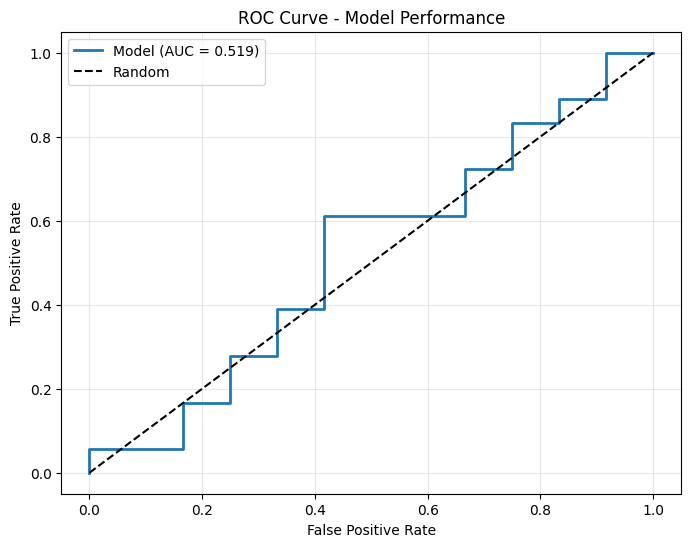

In [9]:
# Calculate AUC for both models
train_auc = roc_auc_score(y_train, train_probs)
test_auc = roc_auc_score(y_test, test_probs)

train_auc_tree = roc_auc_score(y_train, train_probs_tree)
test_auc_tree = roc_auc_score(y_test, test_probs_tree)

print(f"Logistic Regression - Training AUC: {train_auc:.4f}")
print(f"Logistic Regression - Test AUC: {test_auc:.4f}")
print(f"\nDecision Tree - Training AUC: {train_auc_tree:.4f}")
print(f"Decision Tree - Test AUC: {test_auc_tree:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, test_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Model (AUC = {test_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. Calculate KS Statistic

In [10]:
def calculate_ks(y_true, y_pred_proba):
    """
    Calculate Kolmogorov-Smirnov statistic
    """
    # Create dataframe
    df = pd.DataFrame({
        'actual': y_true,
        'predicted': y_pred_proba
    })
    
    # Sort by predicted probability
    df = df.sort_values('predicted', ascending=False).reset_index(drop=True)
    
    # Calculate cumulative percentages
    df['bad_cumsum'] = df['actual'].cumsum()
    df['good_cumsum'] = (1 - df['actual']).cumsum()
    
    total_bad = df['actual'].sum()
    total_good = len(df) - total_bad
    
    df['bad_pct'] = df['bad_cumsum'] / total_bad
    df['good_pct'] = df['good_cumsum'] / total_good
    
    # KS is maximum difference
    df['ks'] = abs(df['bad_pct'] - df['good_pct'])
    
    ks_stat = df['ks'].max()
    ks_index = df['ks'].idxmax()
    
    return ks_stat, ks_index, df

# Calculate KS for test set
ks_value, ks_idx, ks_df = calculate_ks(y_test.values, test_probs)

print(f"KS Statistic: {ks_value:.4f}")
print(f"KS occurs at index: {ks_idx}")

KS Statistic: 0.1944
KS occurs at index: 15


## 10. Create Risk Score

Convert probabilities to a score between 300-900

Score Statistics:
count     30.000000
mean     359.132862
std       18.388410
min      326.047890
25%      349.253400
50%      356.734510
75%      375.164848
max      389.799580
Name: risk_score, dtype: float64


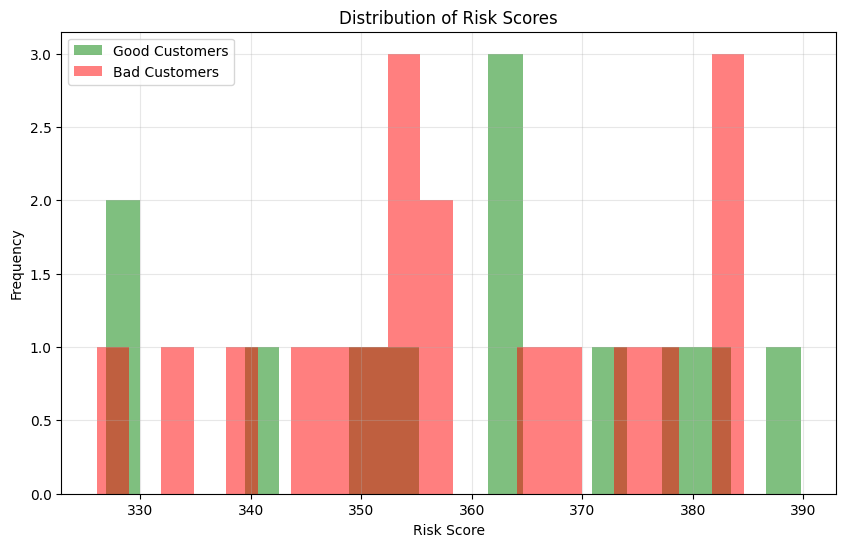

In [11]:
def probability_to_score(prob, base_score=600, pdo=50, base_odds=20):
    """
    Convert probability to credit score
    
    Parameters:
    - base_score: Score at base odds (default 600)
    - pdo: Points to double the odds (default 50)
    - base_odds: Base odds (default 20, meaning 20:1 good:bad)
    """
    # Convert probability to odds
    odds = (1 - prob) / prob
    
    # Calculate score
    factor = pdo / np.log(2)
    offset = base_score - factor * np.log(base_odds)
    score = offset + factor * np.log(odds)
    
    return score

# Calculate scores for test set
test_scores = probability_to_score(test_probs)

# Add to results dataframe
results_df = pd.DataFrame({
    'actual_default': y_test.values,
    'predicted_probability': test_probs,
    'risk_score': test_scores
})

print("Score Statistics:")
print(results_df['risk_score'].describe())

# Plot score distribution
plt.figure(figsize=(10, 6))
plt.hist(results_df[results_df['actual_default']==0]['risk_score'], 
         bins=20, alpha=0.5, label='Good Customers', color='green')
plt.hist(results_df[results_df['actual_default']==1]['risk_score'], 
         bins=20, alpha=0.5, label='Bad Customers', color='red')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.title('Distribution of Risk Scores')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Save Results

In [12]:
# Save model results
results_df.to_excel('model_predictions.xlsx', index=False)

# Save feature importance
feature_importance = pd.DataFrame({
    'feature': numeric_features,
    'coefficient': log_model.coef_[0]
})
feature_importance = feature_importance.sort_values('coefficient', key=abs, ascending=False)
feature_importance.to_excel('feature_importance.xlsx', index=False)

print("Results saved successfully")
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

Results saved successfully

Top 10 Most Important Features:
                    feature  coefficient
3         Outstanding_Loans    -0.224824
5     Total_Current_Balance     0.068786
0   Credit_Card_Utilization    -0.056676
1  Credit_Utilization_Ratio     0.046627
4        Total_Credit_Limit    -0.041737
2  Behavior_Repayment_Score    -0.005999


In [13]:
# Create scorecard from logistic regression coefficients
base_score = 600
pdo = 20  # Points to double odds

# Get coefficients
coef = log_model.coef_[0]
intercept = log_model.intercept_[0]

# Calculate scaling factors
factor = pdo / np.log(2)
offset = base_score - factor * intercept

# Create scorecard
scorecard = pd.DataFrame({
    'Feature': numeric_features,
    'Coefficient': coef,
    'Points_per_Unit': -factor * coef
})

scorecard['Abs_Impact'] = abs(scorecard['Points_per_Unit'])
scorecard = scorecard.sort_values('Abs_Impact', ascending=False)

print("\nCREDIT SCORECARD")
print("="*60)
print(f"Base Score: {base_score}")
print(f"Intercept Adjustment: {offset:.2f}")
print("\nFeature Contributions:")
print(scorecard[['Feature', 'Points_per_Unit']].to_string(index=False))

# Example scoring
print("\n" + "="*60)
print("EXAMPLE: Score Calculation for First Test Customer")
print("="*60)
example = X_test_scaled[0]
score = offset
for i, feat in enumerate(numeric_features):
    contribution = -factor * coef[i] * example[i]
    score += contribution
    print(f"{feat}: {contribution:.1f} points")
print(f"\nFinal Score: {score:.0f}")
print(f"Default Probability: {test_probs[0]:.1%}")



CREDIT SCORECARD
Base Score: 600
Intercept Adjustment: 589.83

Feature Contributions:
                 Feature  Points_per_Unit
       Outstanding_Loans         6.487051
   Total_Current_Balance        -1.984740
 Credit_Card_Utilization         1.635327
Credit_Utilization_Ratio        -1.345366
      Total_Credit_Limit         1.204267
Behavior_Repayment_Score         0.173100

EXAMPLE: Score Calculation for First Test Customer
Credit_Card_Utilization: -1.6 points
Credit_Utilization_Ratio: -2.3 points
Behavior_Repayment_Score: -0.2 points
Outstanding_Loans: 0.6 points
Total_Credit_Limit: 0.1 points
Total_Current_Balance: -1.5 points

Final Score: 585
Default Probability: 62.7%
